# Behaviour Analyses - Machine Learning 

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (GroupKFold, cross_validate,
                                     cross_val_score, LeaveOneGroupOut)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, roc_auc_score

sns.set(font_scale=1.2, style='ticks')
plt.rcParams['figure.dpi'] = 100
SEED = 42


In [21]:
# load data 
data_path = '/Users/martu/Documents/TFG_MARTINA/dataset/CJ_EEG.csv'  
all_df = pd.read_csv(data_path)
print(f'Dataset loaded: {all_df.shape[0]} rows, {all_df.shape[1]} columns')
print(f'Participants: {all_df["subj"].nunique()}')
print(f'Columns: {list(all_df.columns)}')

Dataset loaded: 6600 rows, 36 columns
Participants: 25
Columns: ['exp_ID', 'npar', 'subj', 'nblock', 'ntrial', 'nrep', 'cond-1', 'trial_type', 'rDV', 'deci-3', 'deci-2', 'deci-1', 'cond', 'deci', 'DV', 'resp', 'corr-1', 'r_map', 'correct', 'confi', 'RT', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'o1', 'o2', 'o3', 'o4', 'o5', 'o6', 'metad', 'metad_3%', 'metad_97%']


In [ ]:
df = all_df.copy()

# mofificamos los valores de -1 a 0 para que sean binarios (0 y 1)
df['cond']    = df['cond'].replace({-1: 0}) 
df['correct'] = df['correct'].replace({-1: 0})
df['switch']  = (df['deci'] != df['deci-1']).astype(int) # creamos variable de switch (1 si la decisión actual es diferente a la anterior, 0 si es igual)

# previous confidence
df = df.sort_values(['subj', 'nblock', 'ntrial', 'nrep']).reset_index(drop=True) # ordenamos
df['confi-1']   = df.groupby(['subj', 'nblock', 'ntrial'])['confi'].shift(1) # creamos variable de confianza previa (confi-1) 
df['correct-1'] = df['corr-1'] 

df['is_repeat'] = (df['trial_type'] == 'repeat').astype(int) # variable de si el trial es repeat o no (1 si es repeat, 0 si es switch)
df['deci1_c']   = df['deci-1'] - 0.5  # variable de decisión previa centrada (deci-1 - 0.5) para que tome valores de -0.5 y 0.5 en lugar de 0 y 1

# estandarizamos por participant to avoid scale differences across participants
df['rDV_z']   = df.groupby('subj')['rDV'].transform(
    lambda x: (x - x.mean()) / x.std())
df['RT_z']    = df.groupby('subj')['RT'].transform(
    lambda x: (x - x.mean()) / x.std())
df['confi_z'] = df.groupby('subj')['confi'].transform(
    lambda x: (x - x.mean()) / x.std())
df['confi1_z'] = df.groupby('subj')['confi-1'].transform(
    lambda x: (x - x.mean()) / x.std())

# RT filter (same as behavioural analysis) 
def RT_filter(x, sd=4):
    return x[x['RT'] < x['RT'].mean() + sd * x['RT'].std()]

df = df.groupby('npar', group_keys=False).apply(RT_filter, sd=4).reset_index(drop=True)

print(f'Trials after RT filter: {len(df)}')
print(f'Participants: {df["subj"].nunique()}')

Trials after RT filter: 6537
Participants: 25


In [23]:
# metacognitive efficiency per participant 
# nrep=0 only to avoid contamination from CB

df0 = df[df['nrep'] == 0].copy()

def calc_dprime(x): # la d' es como de bien distingues señal de ruido, es decir, los trials donde la condicion es 1 (señal) frente a los trials donde la condicion es 0 (ruido)
    hits   = ((x["deci"] == 1) & (x["cond"] == 1)).sum() # los hits son los casos donde el participante decidio 1 (deci=1) y la condicion era 1 (cond=1) --> respuesta correcta en trials de señal
    fa     = ((x["deci"] == 1) & (x["cond"] == 0)).sum() # los false alarms son los casos donde el participante decidio 1 (deci=1) pero la condicion era 0 (cond=0) --> respuesta incorrecta en trials de ruido
    noise  = (x["cond"] == 0).sum() # el numero de casos donde la condicion era 0 (cond=0)
    signal = (x["cond"] == 1).sum() # el numero de casos donde la condicion era 1 (cond=1)
    hr  = (hits + 0.5) / (signal + 1) # la tasa de aciertos se calcula como el numero de hits dividido por el numero total de trials de señal (signal) --> se le añade 0.5 al numerador y 1 al denominador para evitar tener una tasa de aciertos de 0 o 1, lo que haria que la d' sea infinita o indefinida
    far = (fa   + 0.5) / (noise  + 1) # la tasa de falsas alarmas se calcula como el numero de false alarms dividido por el numero total de trials de ruido (noise) --> se le añade 0.5 al numerador y 1 al denominador para evitar tener una tasa de falsas alarmas de 0 o 1, lo que haria que la d' sea infinita o indefinida
    return pd.Series({"dprime": norm.ppf(hr) - norm.ppf(far)}) # la d' se calcula como la diferencia entre la tasa de aciertos (hr) y la tasa de falsas alarmas (far), lo que refleja la capacidad del participante para distinguir entre los trials de señal y ruido, independientemente de su sesgo de respuesta

dprime_df  = df0.groupby('subj').apply(calc_dprime, include_groups=False).reset_index() # calculamos d' para cada participante

# la meta d' es que tan bien usa el participante su confianza para distinguir sus aciertos de sus errores
metad_subj = df.groupby('subj')['metad'].first().reset_index() # cogemos el valor de metad por participante (es el mismo para todos los trials de un mismo participante, por eso usamos .first())
eff_df     = metad_subj.merge(dprime_df, on='subj') # unimos la d' con la meta d' por participante p
eff_df['metad_eff'] = eff_df['metad'] / eff_df['dprime'] # la eficiencia metacognitiva se calcula como la meta d' dividida por la d'

df = df.merge(eff_df[['subj', 'metad_eff']], on='subj', how='left')

print('metacognitive efficiency calculada')
print(eff_df[['subj', 'dprime', 'metad', 'metad_eff']].round(3))

metacognitive efficiency calculada
   subj  dprime  metad  metad_eff
0   S03   1.397  0.556      0.398
1   s01   1.123  0.086      0.077
2   s04   1.358  0.591      0.435
3   s05   1.477  0.558      0.378
4   s07   1.118  0.596      0.533
5   s08   1.039  0.727      0.700
6   s09   1.049  1.107      1.055
7   s10   1.026  1.217      1.187
8   s11   0.882  0.509      0.577
9   s12   1.306  0.487      0.373
10  s13   1.185  0.794      0.670
11  s14   1.084  0.586      0.541
12  s15   1.253  0.913      0.728
13  s16   1.125  0.296      0.263
14  s17   1.238  1.106      0.894
15  s18   1.258  0.195      0.155
16  s19   1.191  0.578      0.485
17  s20   1.362  0.596      0.437
18  s21   1.168  0.359      0.307
19  s22   1.104  1.226      1.111
20  s23   1.395  0.444      0.318
21  s24   1.526    NaN        NaN
22  s25   1.470  0.906      0.616
23  s26   1.199  0.248      0.207
24  s27   1.488  0.400      0.269


In [24]:
# feature definition --> organizamos las variables en 4 grupos para luego analizarlas por separado y ver su importancia relativa 

sensory_features  = ['rDV_z', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6']
history_features  = ['deci-1', 'deci-2', 'deci-3', 'corr-1', 'confi1_z']
behav_features    = ['RT_z', 'nrep', 'is_repeat']
meta_features     = ['metad_eff']

all_features = sensory_features + history_features + behav_features + meta_features

# TARGET 1: switch — did the participant change their decision?
# TARGET 2: deci — cardinal (0) or diagonal (1)?

print('Features by group:')
print(f'  Sensoriales  ({len(sensory_features)}): {sensory_features}')
print(f'  Historia/CB  ({len(history_features)}): {history_features}')
print(f'  Behaviourales ({len(behav_features)}): {behav_features}')
print(f'  Metacognition ({len(meta_features)}): {meta_features}')
print(f'  TOTAL: {len(all_features)} features')

Features by group:
  Sensoriales  (7): ['rDV_z', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6']
  Historia/CB  (5): ['deci-1', 'deci-2', 'deci-3', 'corr-1', 'confi1_z']
  Behaviourales (3): ['RT_z', 'nrep', 'is_repeat']
  Metacognition (1): ['metad_eff']
  TOTAL: 16 features


In [25]:
# prepare datasets per target 

# TARGET 1: switch (nrep > 0 only) — did the participant change their decision?
df_switch = df[df['nrep'] > 0].dropna( # filtramos nrep > 0 porque el switch solo tiene sentido si hay una decision anterior y limpiamos
    subset=all_features + ['switch', 'subj'] 
).reset_index(drop=True)

X_sw    = df_switch[all_features].values
y_sw    = df_switch['switch'].values
groups_sw = df_switch['npar'].values

print('TARGET 1: switch')
print(f'Trials: {len(df_switch)} | Participants: {df_switch["subj"].nunique()}')
n_sw   = (y_sw == 0).sum()
n_rep  = (y_sw == 1).sum()
print(f'Mantiene (0): {n_sw} ({n_sw/len(y_sw)*100:.1f}%)  |  Cambia (1): {n_rep} ({n_rep/len(y_sw)*100:.1f}%)') # balance de clases?

# TARGET 2: deci (all nrep) - cardinal (0) o diagonal (1)

# aqui usamos todos los trials
df_deci = df.dropna(subset=sensory_features + behav_features + meta_features + ['deci', 'subj']).copy()
for col in history_features:
    if col in df_deci.columns:
        df_deci[col] = df_deci[col].fillna(0)  # las history features (deci-1, confi1_z...) son NaN en nrep=0 porque no hay trial anterior, pero, en lugar de eliminarlos, se rellenan con 0

X_dc      = df_deci[all_features].values
y_dc      = df_deci['deci'].values
groups_dc = df_deci['npar'].values

print('\nTARGET 2: deci')
print(f'Trials: {len(df_deci)} | Participants: {df_deci["subj"].nunique()}')
n_card = (y_dc == 0).sum()
n_diag = (y_dc == 1).sum()
print(f'Cardinal (0): {n_card} ({n_card/len(y_dc)*100:.1f}%)  |  Diagonal (1): {n_diag} ({n_diag/len(y_dc)*100:.1f}%)')

TARGET 1: switch
Trials: 4195 | Participants: 24
Mantiene (0): 3592 (85.6%)  |  Cambia (1): 603 (14.4%)

TARGET 2: deci
Trials: 6274 | Participants: 24
Cardinal (0): 2766 (44.1%)  |  Diagonal (1): 3508 (55.9%)


In [26]:
# model definition

# para garantizar generalizacion a nuevos participantes
N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS) # en cada fold, el modelo se entrena con participantes de 4 grupos y se testa con el 5 grupo, asi nunca ve los mismos participantes en train y test

# DEFINIMOS LOS 4 MODELOS --> TODOS COMO PIPELINES, ES DECIR, CON UN ESTANDARIZADOR (STANDARD SCALER) SEGUIDO DEL CLASIFICADOR ( ASI EL ESTANDARIZADO SE APLICA SOLO A LOS DATOS DE ENTRENAMIENTO EN CADA FOLD Y LUEGO SE TRANSFORMAN LOS DATOS DE TEST CON LOS PARAMETROS CALCULADOS EN EL TRAINING )
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced',  # compensates class imbalance
            max_iter=1000,
            C=1.0,
            random_state=SEED
        ))
    ]),
    'SVM (lineal)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='linear',
            class_weight='balanced',
            probability=True,
            C=1.0,
            random_state=SEED
        ))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=300, # 300 arboles
            max_depth=8, # regularised to prevent overfitting
            min_samples_leaf=20,
            class_weight='balanced',
            random_state=SEED,
            n_jobs=-1
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.05,    # low learning rate = less overfitting, cada arbol contribuye poco, aprende lentamente, pero mas robusto
            max_depth=3,
            subsample=0.8, # cada arbol se entrena con una muestra aleatoria del 80% de los datos, lo que ayuda a reducir el overfitting
            random_state=SEED
        ))
    ])
}

scoring = {
    'accuracy': 'accuracy',
    'auc'     : 'roc_auc',
    'f1'      : 'f1'
}

print(f'Models defined: {list(models.keys())}')
print(f'Validation: GroupKFold (k={N_FOLDS}, groups=participants)')

Models defined: ['Logistic Regression', 'SVM (lineal)', 'Random Forest', 'Gradient Boosting']
Validation: GroupKFold (k=5, groups=participants)


In [27]:
# Training — TARGET 1: switch 
print('Training models — TARGET: switch (decision change?)')
print('=' * 60)

results_sw = {}

# entrenaremos los 4 modelos con validacion cruzada por grupos (participants) y guardaremos los resultados de accuracy, AUC y F1 tanto en train como en test para cada modelo
for name, pipeline in models.items():
    print(f'  {name}...', end=' ')

    # le damos el pipeline, los datos de switch, las etiquetas de switch, los grupos de participantes para la validacion cruzada, el tipo de validacion cruzada (GroupKFold), las metricas a calcular (accuracy, AUC y F1)   
    cv = cross_validate(
        pipeline, # pipeline = es el modelo que queremos entrenar
        X_sw, # datos de switch (features)
        y_sw, # etiquetas de switch (target) que tiene que predecir el modelo
        groups=groups_sw, # grupos de participantes para la validacion cruzada, asi se asegura que en cada fold el modelo se entrena con participantes diferentes a los del test         
        cv=gkf, # tipo de validacion cruzada (GroupKFold)
        scoring=scoring, # metricas a calcular (accuracy, AUC y F1)
        return_train_score=True, # para poder calcular el overfitting (train accuracy - test accuracy)
        n_jobs=-1 # para usar todos los cores disponibles y acelerar el proceso de entrenamiento
    )
    results_sw[name] = {
        'acc_test' : cv['test_accuracy'],
        'acc_train': cv['train_accuracy'],
        'auc_test' : cv['test_auc'],
        'f1_test'  : cv['test_f1'],
    }
    acc  = cv['test_accuracy'].mean()
    auc  = cv['test_auc'].mean()
    over = cv['train_accuracy'].mean() - acc
    print(f'Acc={acc:.3f}  AUC={auc:.3f}  Overfit={over:.3f}')

print('\nTraining complete')

Training models — TARGET: switch (decision change?)
  Logistic Regression... Acc=0.677  AUC=0.735  Overfit=0.010
  SVM (lineal)... Acc=0.678  AUC=0.731  Overfit=0.010
  Random Forest... Acc=0.729  AUC=0.745  Overfit=0.082
  Gradient Boosting... Acc=0.841  AUC=0.737  Overfit=0.062

Training complete


In [28]:
# Training — TARGET 2: deci 
print('Training models — TARGET: deci (cardinal vs diagonal)')
print('=' * 60)

results_dc = {}

for name, pipeline in models.items():
    print(f'  {name}...', end=' ')
    cv = cross_validate(
        pipeline, 
        X_dc, 
        y_dc,
        groups=groups_dc,
        cv=gkf,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    results_dc[name] = {
        'acc_test' : cv['test_accuracy'],
        'acc_train': cv['train_accuracy'],
        'auc_test' : cv['test_auc'],
        'f1_test'  : cv['test_f1'],
    }
    acc  = cv['test_accuracy'].mean()
    auc  = cv['test_auc'].mean()
    over = cv['train_accuracy'].mean() - acc
    print(f'Acc={acc:.3f}  AUC={auc:.3f}  Overfit={over:.3f}')

print('\nTraining complete')

Training models — TARGET: deci (cardinal vs diagonal)
  Logistic Regression... Acc=0.784  AUC=0.861  Overfit=0.005
  SVM (lineal)... Acc=0.763  AUC=0.852  Overfit=0.005
  Random Forest... Acc=0.811  AUC=0.885  Overfit=0.032
  Gradient Boosting... Acc=0.803  AUC=0.879  Overfit=0.052

Training complete


In [29]:
# comparative results table 

def make_results_table(results_dict, label):
    rows = []
    for name, res in results_dict.items():
        rows.append({
            'Model'     : name,
            'Acc'       : f"{res['acc_test'].mean():.3f} ± {res['acc_test'].std():.3f}",
            'AUC-ROC'   : f"{res['auc_test'].mean():.3f} ± {res['auc_test'].std():.3f}",
            'F1'        : f"{res['f1_test'].mean():.3f} ± {res['f1_test'].std():.3f}",
            'Train Acc' : f"{res['acc_train'].mean():.3f}",
            'Overfit'   : f"{res['acc_train'].mean() - res['acc_test'].mean():.3f}"
        })
    df_res = pd.DataFrame(rows)
    print(f'\n── Target: {label} ──────────────────────────────────────────')
    print(df_res.to_string(index=False))
    return df_res

table_sw = make_results_table(results_sw, 'switch (decision change?)')
table_dc = make_results_table(results_dc, 'deci (cardinal vs diagonal)')


── Target: switch (decision change?) ──────────────────────────────────────────
              Model           Acc       AUC-ROC            F1 Train Acc Overfit
Logistic Regression 0.677 ± 0.018 0.735 ± 0.014 0.368 ± 0.063     0.687   0.010
       SVM (lineal) 0.678 ± 0.027 0.731 ± 0.011 0.375 ± 0.069     0.688   0.010
      Random Forest 0.729 ± 0.030 0.745 ± 0.012 0.367 ± 0.063     0.811   0.082
  Gradient Boosting 0.841 ± 0.027 0.737 ± 0.013 0.132 ± 0.033     0.903   0.062

── Target: deci (cardinal vs diagonal) ──────────────────────────────────────────
              Model           Acc       AUC-ROC            F1 Train Acc Overfit
Logistic Regression 0.784 ± 0.015 0.861 ± 0.010 0.799 ± 0.022     0.789   0.005
       SVM (lineal) 0.763 ± 0.024 0.852 ± 0.015 0.785 ± 0.029     0.768   0.005
      Random Forest 0.811 ± 0.011 0.885 ± 0.011 0.826 ± 0.016     0.843   0.032
  Gradient Boosting 0.803 ± 0.009 0.879 ± 0.013 0.823 ± 0.017     0.855   0.052


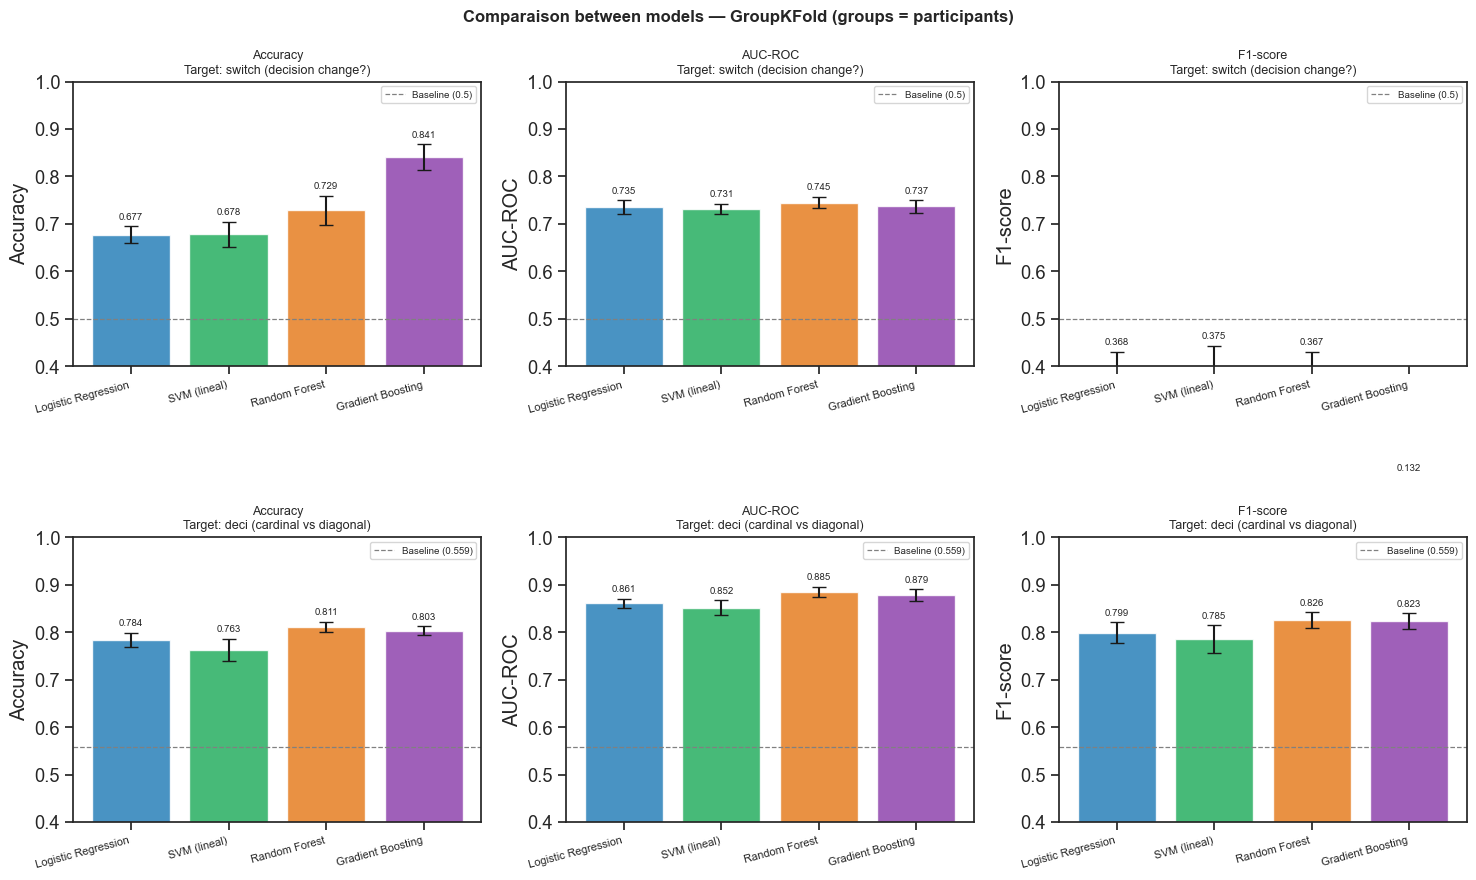

Figure saved: fig_model_comparison.png


In [30]:
# model comparison figure 

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
colors_m = ['#2980b9', '#27ae60', '#e67e22', '#8e44ad']
names = list(models.keys())

for row_idx, (results, target_label, baseline) in enumerate([ # iteramos sobre los resultados de switch y deci
    (results_sw, 'switch (decision change?)',       0.5),
    (results_dc, 'deci (cardinal vs diagonal)', 0.559)
]):
    for col_idx, (metric_key, metric_label) in enumerate([ # iteramos sobre las metricas de test (accuracy, AUC y F1)
        ('acc_test', 'Accuracy'),
        ('auc_test', 'AUC-ROC'),
        ('f1_test',  'F1-score')
    ]):
        ax = axes[row_idx, col_idx]
        means = [results[m][metric_key].mean() for m in names] # calculamos la media de cada metrica para cada modelo
        stds  = [results[m][metric_key].std()  for m in names] # calculamos la desviacion estandar de cada metrica para cada modelo

        bars = ax.bar(names, means, yerr=stds, capsize=5,
                      color=colors_m, alpha=0.85)
        ax.axhline(baseline, color='gray', linestyle='--',
                   linewidth=0.9, label=f'Baseline ({baseline})')
        ax.set_title(f'{metric_label}\nTarget: {target_label}', fontsize=9)
        ax.set_ylabel(metric_label)
        ax.set_ylim(0.4, 1.0)
        ax.set_xticklabels(names, rotation=15, ha='right', fontsize=8)
        ax.legend(fontsize=7)
        for bar, mean, std in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width()/2,
                    mean + std + 0.01,
                    f'{mean:.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Comparaison between models — GroupKFold (groups = participants)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_model_comparison.png')

In [31]:
# feature ablation = eliminar grupos de features para ver su impacto en el rendimiento del modelo, asi podemos ver cuales grupos de features son mas importantes para predecir cada target (switch y deci)
# lo que hacemos es entrenar el mismo modelo (el mejor de los anteriores) pero con diferentes grupos de features
# AÑADIENDO PROGRESIVAMENTE LOS GRUPOS DE FEATURES: primero solo las sensoriales, luego añadiendo las de historia, luego los de comportamiento y finalmente las metacognitivas

feature_sets = {
    '1. Sensory'              : sensory_features,
    '2. + History/CB'         : sensory_features + history_features,
    '3. + Behavioural'        : sensory_features + history_features + behav_features,
    '4. + Metacognition'      : all_features
}

ablation_results = {}

# iteramos sobre cada conjunto de features (sensory, sensory+history, sensory+history+behav, all) y entrenamos el modelo para cada target (switch y deci) con esas features, luego guardamos los resultados de accuracy y AUC para cada combinacion de features y target
for feat_label, feat_list in feature_sets.items():
    ablation_results[feat_label] = {}
    for target_label, (X_t, y_t, groups_t) in [
        ('switch', (X_sw, y_sw, groups_sw)), # para el target de switch usamos los datos de switch (X_sw, y_sw, groups_sw)
        ('deci',   (X_dc, y_dc, groups_dc)) # para el target de deci usamos los datos de deci (X_dc, y_dc, groups_dc)
    ]:
        feat_idx = [all_features.index(f) for f in feat_list if f in all_features] # obtenemos los indices de las features que queremos usar en este conjunto (por ejemplo, para el conjunto 2, serian los indices de las features sensoriales + historia)
        X_sub    = X_t[:, feat_idx] if target_label == 'switch' else X_dc[:, feat_idx] # seleccionamos solo las columnas de las features que queremos usar para entrenar el modelo, dependiendo del target (switch o deci)
        groups_use = groups_sw if target_label == 'switch' else groups_dc # seleccionamos los grupos de participantes correspondientes al target (switch o deci)

        if target_label == 'switch':
            model_abl = Pipeline([
                ('scaler', StandardScaler()),
                ('clf', LogisticRegression( # el modelo que mejor funciono para switch fue la regresion logistica, por eso lo usamos para la ablacion de switch
                    class_weight='balanced', max_iter=1000, random_state=SEED
                ))
            ])
        else:
            model_abl = Pipeline([
                ('scaler', StandardScaler()),
                ('clf', RandomForestClassifier( # el modelo que mejor funciono para deci fue el random forest, por eso lo usamos para la ablacion de deci
                    n_estimators=300, max_depth=8, min_samples_leaf=20,
                    class_weight='balanced', random_state=SEED, n_jobs=-1
                ))
            ])

        cv = cross_validate( # entrenamos el modelo de ablacion con validacion cruzada por grupos (participants) y guardamos los resultados de accuracy y AUC para cada combinacion de features y target
            model_abl, X_sub, y_t,
            groups=groups_use,
            cv=GroupKFold(n_splits=N_FOLDS),
            scoring=scoring,
            n_jobs=-1
        )

        ablation_results[feat_label][target_label] = {
            'acc'    : cv['test_accuracy'].mean(),
            'acc_std': cv['test_accuracy'].std(),
            'auc'    : cv['test_auc'].mean(),
            'auc_std': cv['test_auc'].std(),
        }
        print(f'{feat_label} | {target_label}: '
              f'Acc={cv["test_accuracy"].mean():.3f}  '
              f'AUC={cv["test_auc"].mean():.3f}')

print('\nablation complete')

1. Sensory | switch: Acc=0.538  AUC=0.548
1. Sensory | deci: Acc=0.724  AUC=0.803
2. + History/CB | switch: Acc=0.665  AUC=0.728
2. + History/CB | deci: Acc=0.804  AUC=0.878
3. + Behavioural | switch: Acc=0.685  AUC=0.742
3. + Behavioural | deci: Acc=0.811  AUC=0.884
4. + Metacognition | switch: Acc=0.677  AUC=0.735
4. + Metacognition | deci: Acc=0.811  AUC=0.885

ablation complete


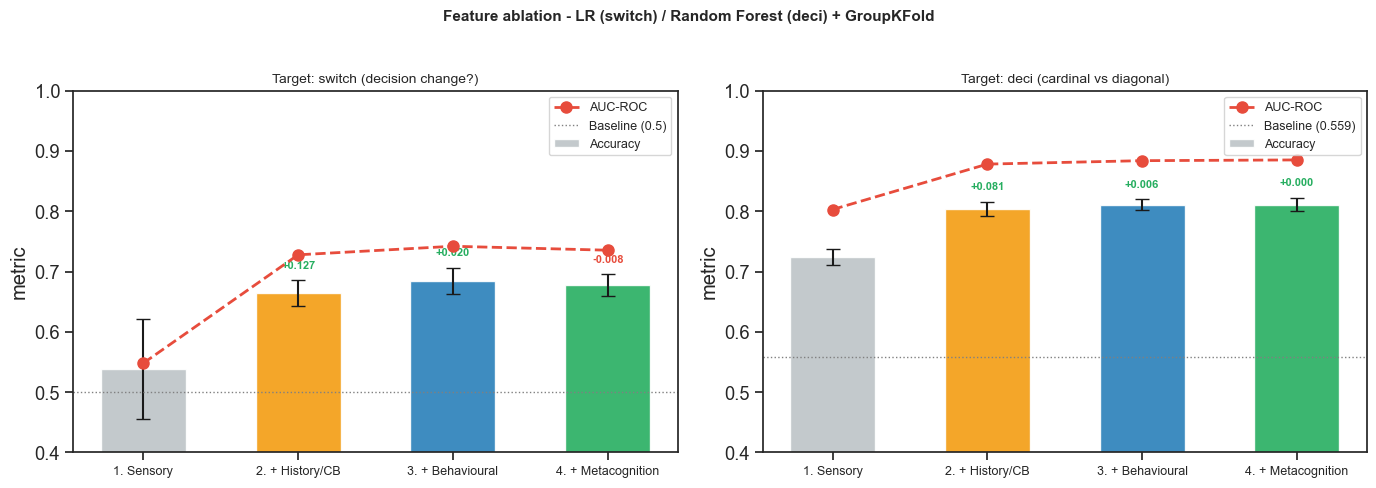

Figure saved: fig_ablation.png


In [32]:
# feature ablation figure 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feature_sets = {
    '1. Sensory'              : sensory_features,
    '2. + History/CB'         : sensory_features + history_features,
    '3. + Behavioural'        : sensory_features + history_features + behav_features,
    '4. + Metacognition'      : all_features
}

set_labels = list(feature_sets.keys())
colors_abl = ['#bdc3c7', '#f39c12', '#2980b9', '#27ae60']

for ax, target_label, baseline, title in zip(
    axes,
    ['switch', 'deci'],
    [0.5, 0.559],
    ['Target: switch (decision change?)', 'Target: deci (cardinal vs diagonal)']
):
    accs = [ablation_results[s][target_label]['acc']     for s in set_labels] # obtenemos las medias de accuracy para cada conjunto de features y el target correspondiente
    stds = [ablation_results[s][target_label]['acc_std'] for s in set_labels] # obtenemos las desviaciones estandar de accuracy para cada conjunto de features y el target correspondiente
    aucs = [ablation_results[s][target_label]['auc']     for s in set_labels] # obtenemos las medias de AUC para cada conjunto de features y el target correspondiente

    x    = np.arange(len(set_labels))
    bars = ax.bar(x, accs, yerr=stds, capsize=5,
                  color=colors_abl, alpha=0.9, width=0.55, label='Accuracy')
    ax.plot(x, aucs, 'o--', color='#e74c3c', linewidth=2,
            markersize=8, label='AUC-ROC', zorder=5)
    ax.axhline(baseline, color='gray', linestyle=':', linewidth=1,
               label=f'Baseline ({baseline})')

    ax.set_xticks(x)
    ax.set_xticklabels(set_labels, fontsize=9)
    ax.set_ylim(0.4, 1.0)
    ax.set_ylabel('metric')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)

    for i in range(1, len(accs)):
        gain  = accs[i] - accs[i-1] # calculamos el gain de accuracy al añadir cada grupo de features, comparando con el conjunto anterior (por ejemplo, el gain de añadir las features de historia se calcula como la accuracy del conjunto 2 menos la accuracy del conjunto 1)
        color = '#27ae60' if gain > 0 else '#e74c3c'
        ax.annotate(f'{gain:+.3f}',
                    xy=(i, accs[i] + stds[i] + 0.02),
                    ha='center', fontsize=8, color=color, fontweight='bold')

plt.suptitle('Feature ablation - LR (switch) / Random Forest (deci) + GroupKFold\n',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ablation.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_ablation.png')

In [33]:
# permutation importance = tecnica para medir cuanto aporta cada variable al modelo
# lo que hace es entrenar el modelo con todas las features, luego permuta aleatoriamente los valores de una feature y mide cuanto empeora el rendimiento del modelo, si el rendimiento empeora mucho, significa que esa feature es importante para el modelo, si no cambia apenas, significa que esa feature no aporta mucho al modelo
# trained on all data

def compute_perm_importance(X, y, groups, feature_names, n_repeats=50):

    gkf_pi = GroupKFold(n_splits=N_FOLDS)
    splits = list(gkf_pi.split(X, y, groups)) 

    largest_fold = max(splits, key=lambda s: len(s[1])) # seleccionamos el fold con mas muestras de test para entrenar el modelo con ese fold, asi tenemos mas datos para entrenar el modelo y obtener una importancia de variables mas estable
    train_idx, test_idx = largest_fold

    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr) # escalamos las features de entrenamiento
    X_te_s = scaler.transform(X_te) # escalamos las features de test

    # entrenamos el modelo con todas las features usando el fold seleccionado
    # usamos gradient boosting porque es el modelo que mejor funciono para deci y el segundo mejor para switch, ademas de ser un modelo potente y robusto que suele dar buenas importancias de variables
    gb = GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=3, subsample=0.8, random_state=SEED
    )
    gb.fit(X_tr_s, y_tr)

    perm = permutation_importance(
        gb, X_te_s, y_te,
        n_repeats=n_repeats, # n_repeats=50 significa que cada variable se desordena 50 veces y se promedia el resultado
        random_state=SEED,
        scoring='roc_auc',
        n_jobs=-1
    )

    return pd.DataFrame({
        'feature'  : feature_names,
        'imp_mean' : perm.importances_mean,
        'imp_std'  : perm.importances_std
    }).sort_values('imp_mean', ascending=False) # devuelve un dataframe con la importancia media y la desviacion estandar de cada feature, ordenado de mayor a menor importancia

print('Computing permutation importance — switch...')
perm_sw = compute_perm_importance(X_sw, y_sw, groups_sw, all_features)

print('Computing permutation importance — deci...')
perm_dc = compute_perm_importance(X_dc, y_dc, groups_dc, all_features)

print('\nTop 8 variables — switch:')
print(perm_sw.head(8).round(4).to_string(index=False))
print('\nTop 8 variables — deci:')
print(perm_dc.head(8).round(4).to_string(index=False))

Computing permutation importance — switch...
Computing permutation importance — deci...

Top 8 variables — switch:
  feature  imp_mean  imp_std
   corr-1    0.0919   0.0134
 confi1_z    0.0847   0.0129
     RT_z    0.0279   0.0077
metad_eff    0.0172   0.0064
    rDV_z    0.0125   0.0047
       d6    0.0032   0.0033
       d1    0.0024   0.0041
       d3    0.0013   0.0022

Top 8 variables — deci:
 feature  imp_mean  imp_std
  deci-1    0.1430   0.0070
   rDV_z    0.1179   0.0095
    nrep    0.0191   0.0031
confi1_z    0.0089   0.0018
  deci-2    0.0045   0.0007
      d6    0.0039   0.0019
    RT_z    0.0032   0.0016
      d1    0.0016   0.0009


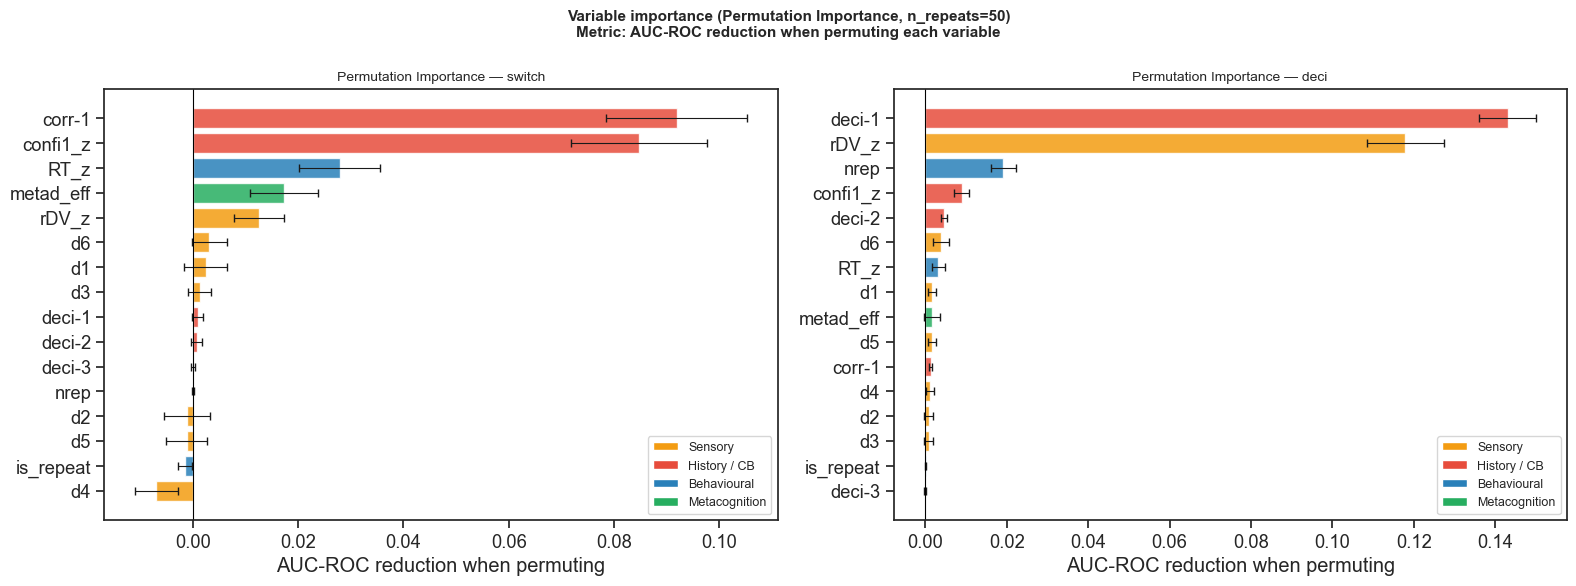

Figure saved: fig_permutation_importance.png


In [34]:
# permutation importance figure 

color_map = {}
for f in all_features: # asignamos un color a cada feature segun su grupo (sensory, history, behav o meta) 
    if f in sensory_features : color_map[f] = '#f39c12'
    elif f in history_features: color_map[f] = '#e74c3c'
    elif f in behav_features  : color_map[f] = '#2980b9'
    else                      : color_map[f] = '#27ae60'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, perm_df, title in zip(
    axes,
    [perm_sw, perm_dc],
    ['Permutation Importance — switch', 'Permutation Importance — deci']
):
    colors_pi = [color_map[f] for f in perm_df['feature']]
    ax.barh(perm_df['feature'], perm_df['imp_mean'],
            xerr=perm_df['imp_std'], color=colors_pi, alpha=0.85,
            capsize=3, error_kw={'linewidth': 0.8})
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('AUC-ROC reduction when permuting')
    ax.set_title(title, fontsize=10)
    ax.invert_yaxis()

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#f39c12', label='Sensory'),
        Patch(facecolor='#e74c3c', label='History / CB'),
        Patch(facecolor='#2980b9', label='Behavioural'),
        Patch(facecolor='#27ae60', label='Metacognition'),
    ]
    ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.suptitle('Variable importance (Permutation Importance, n_repeats=50)\n'
             'Metric: AUC-ROC reduction when permuting each variable',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_permutation_importance.png')

In [35]:
# grouped importance by feature category --> sumamos la importancia de las variables por grupo (sensory, history, behav, meta) para ver cuales grupos de features son mas importantes en general para predecir cada target (switch y deci)

groups_def = {
    'Sensory'    : sensory_features,
    'History / CB': history_features,
    'Behavioural'   : behav_features,
    'Metacognition': meta_features
}

print('Grouped importance by variable category:\n')
for perm_df, target_label in [(perm_sw, 'switch'), (perm_dc, 'deci')]:
    print(f'── Target: {target_label} ──────────────────────────────────')
    group_imp = []
    for grp_name, feats in groups_def.items():
        mask = perm_df['feature'].isin(feats)
        total = perm_df[mask]['imp_mean'].sum() # sumamos la importancia media de las variables que pertenecen a ese grupo para obtener una importancia total del grupo
        group_imp.append({'Group': grp_name, 'Total importance': total})
    gi_df = pd.DataFrame(group_imp).sort_values('Total importance', ascending=False)
    print(gi_df.round(4).to_string(index=False))
    print()

Grouped importance by variable category:

── Target: switch ──────────────────────────────────
        Group  Total importance
 History / CB            0.1783
  Behavioural            0.0264
Metacognition            0.0172
      Sensory            0.0102

── Target: deci ──────────────────────────────────
        Group  Total importance
 History / CB            0.1577
      Sensory            0.1278
  Behavioural            0.0224
Metacognition            0.0016



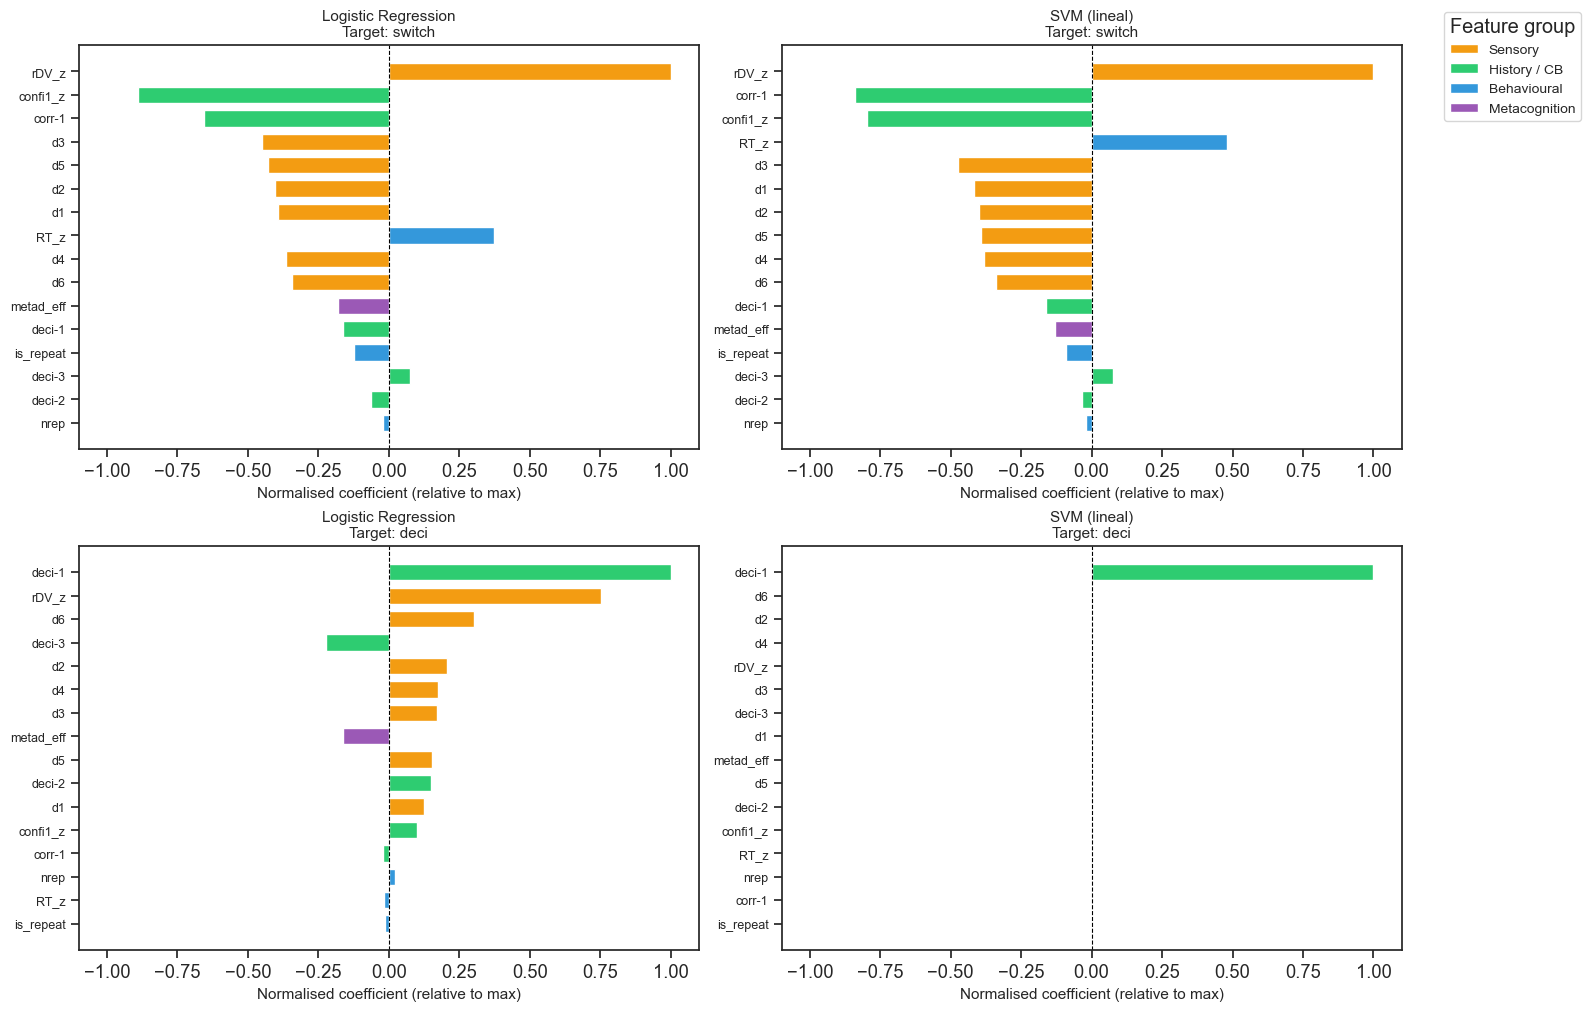

In [ ]:
# coeficiente de los modelos lineales
# lo que hacemos es entrenar cada modelo con todos los datos (no con CV) para extraer los coeficientes = INTERPRETACION

color_map = {}
for f in all_features:
    if f in sensory_features:   color_map[f] = '#f39c12'
    elif f in history_features: color_map[f] = '#2ecc71'
    elif f in behav_features:   color_map[f] = '#3498db'
    else:                       color_map[f] = '#9b59b6'

linear_models = ['Logistic Regression', 'SVM (lineal)']
targets = [
    ('switch', df_switch, y_sw),
    ('deci',   df_deci,   y_dc),
]

fig, axes = plt.subplots(
    len(targets), len(linear_models),
    figsize=(14, 5 * len(targets)),
    constrained_layout=True
)

for row, (target_name, X, y) in enumerate(targets): # iteramos sobre los targets (switch y deci) y sus respectivos datasets 
    for col, model_name in enumerate(linear_models):
        ax = axes[row, col]

        pipe = models[model_name] # cogemos el pipeline del modelo lineal (regresion logistica o SVM lineal) que definimos antes, que incluye un estandarizador y el clasificador
        pipe.fit(X[all_features], y) # entrenamos el modelo con todas las features para obtener los coeficientes finales, no usamos CV 
        coefs = pipe.named_steps['clf'].coef_[0] # extraemos los coeficientes del clasificador (coef_[0])

        max_abs = np.abs(coefs).max() # calculamos el valor absoluto maximo de los coeficientes para normalizarlos, asi podemos comparar la importancia relativa de las variables 
        coefs_norm = coefs / max_abs if max_abs > 0 else coefs # normalizamos dividiendo por el valor absoluto maximo

        coef_df = pd.DataFrame({
            'feature': all_features,
            'coef':    coefs_norm,
            'color':   [color_map[f] for f in all_features],
        }).sort_values('coef', key=abs, ascending=True)

        ax.barh(coef_df['feature'], coef_df['coef'],
                color=coef_df['color'], edgecolor='white', height=0.7)
        ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlim(-1.1, 1.1)
        ax.set_xlabel('Normalised coefficient (relative to max)', fontsize=11)
        ax.set_title(f'{model_name}\nTarget: {target_name}', fontsize=11)
        ax.tick_params(axis='y', labelsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#f39c12', label='Sensory'),
    Patch(facecolor='#2ecc71', label='History / CB'),
    Patch(facecolor='#3498db', label='Behavioural'),
    Patch(facecolor='#9b59b6', label='Metacognition'),
]
fig.legend(handles=legend_elements, loc='upper right',
           bbox_to_anchor=(1.13, 1), fontsize=10, title='Feature group')
plt.show()


In [38]:
# performance by nrep --> miramos si el modelo mejora segun el numero de nrep

results_nrep = {0: {}, 1: {}, 2: {}}

# DECIIIII
for nrep_val in [0, 1, 2]: # iteramos sobre los valores de nrep (0, 1 y 2) y entrenamos un modelo para cada nrep
    for target_col, df_t, feat_list in [
        ('deci',   df_deci, all_features), # deci: all nrep
    ]:
        mask = df_t['nrep'] == nrep_val # para cada nrep, filtramos el dataframe para quedarnos solo con los trials de ese nrep
        sub  = df_t[mask].dropna(subset=feat_list + [target_col, 'subj']) # limpiamos
        if sub['subj'].nunique() < N_FOLDS: # si el numero de participantes es menor que el numero de folds, no podemos hacer la validacion cruzada por grupos, asi que saltamos ese nrep para ese target
            print(f'nrep={nrep_val}, {target_col}: pocos participants, saltando')
            continue

        X_sub = sub[feat_list].values # seleccionamos las features que queremos usar para entrenar el modelo, dependiendo del target (en este caso, usamos todas las features para deci)
        y_sub = sub[target_col].values # seleccionamos las etiquetas del target que queremos predecir (en este caso, deci)
        g_sub = sub['subj'].values # seleccionamos los grupos de participantes para la validacion cruzada por grupos

        gb_sub = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', GradientBoostingClassifier( # usamos gradient boosting 
                n_estimators=300, learning_rate=0.05,
                max_depth=3, subsample=0.8, random_state=SEED
            ))
        ])

        # entrenamos el modelo de switch con validacion cruzada por grupos para ese nrep 
        cv = cross_validate(gb_sub, X_sub, y_sub, groups=g_sub,
                            cv=GroupKFold(n_splits=min(N_FOLDS, sub['subj'].nunique())), 
                            scoring=scoring, n_jobs=-1)
        results_nrep[nrep_val][target_col] = {
            'acc': cv['test_accuracy'],
            'auc': cv['test_auc'],
            'n'  : len(sub)
        }
        print(f'nrep={nrep_val}, {target_col} (n={len(sub)}): '
              f'Acc={cv["test_accuracy"].mean():.3f}  AUC={cv["test_auc"].mean():.3f}')

# SWIIIITCH
# nrep 1 and 2 only (requires a previous decision)

for nrep_val in [1, 2]: # iteramos sobre los valores de nrep (1 y 2) para el target de switch
    sub  = df_switch[mask].dropna(subset=all_features + ['switch', 'subj']) # filtramos el dataframe de switch para quedarnos solo con los trials de ese nrep y limpiamos, usando todas las features para switch
    if sub['subj'].nunique() < N_FOLDS: # si el numero de participantes es menor que el numero de folds, no podemos hacer la validacion cruzada por grupos, asi que saltamos ese nrep para switch
        continue
    X_sub = sub[all_features].values # seleccionamos todas las features para entrenar el modelo de switch, independientemente del nrep, porque el objetivo aqui es ver si el rendimiento del modelo mejora o empeora segun el nrep, no queremos cambiar las features que usamos para entrenar el modelo
    y_sub = sub['switch'].values # seleccionamos las etiquetas de switch para entrenar el modelo de switch
    g_sub = sub['subj'].values # seleccionamos los grupos de participantes para la validacion cruzada por grupos para el modelo de switch
    gb_sub = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier( # usamos gradient boosting para el modelo de switch, aunque no fue el mejor modelo para switch, es un modelo potente y robusto 
            n_estimators=300, learning_rate=0.05,
            max_depth=3, subsample=0.8, random_state=SEED
        ))
    ])
    # entrenamos el modelo de switch con validacion cruzada por grupos para ese nrep 
    cv = cross_validate(gb_sub, X_sub, y_sub, groups=g_sub,
                        cv=GroupKFold(n_splits=min(N_FOLDS, sub['subj'].nunique())),
                        scoring=scoring, n_jobs=-1)
    
    if 'switch' not in results_nrep[nrep_val]:
        results_nrep[nrep_val]['switch'] = {}
    results_nrep[nrep_val]['switch'] = {
        'acc': cv['test_accuracy'],
        'auc': cv['test_auc'],
        'n'  : len(sub)
    }
    print(f'nrep={nrep_val}, switch  (n={len(sub)}): '
          f'Acc={cv["test_accuracy"].mean():.3f}  AUC={cv["test_auc"].mean():.3f}')

nrep=0, deci (n=2079): Acc=0.709  AUC=0.786
nrep=1, deci (n=2100): Acc=0.832  AUC=0.894
nrep=2, deci (n=2095): Acc=0.862  AUC=0.920
nrep=1, switch  (n=1398): Acc=0.828  AUC=0.709
nrep=2, switch  (n=1398): Acc=0.828  AUC=0.709


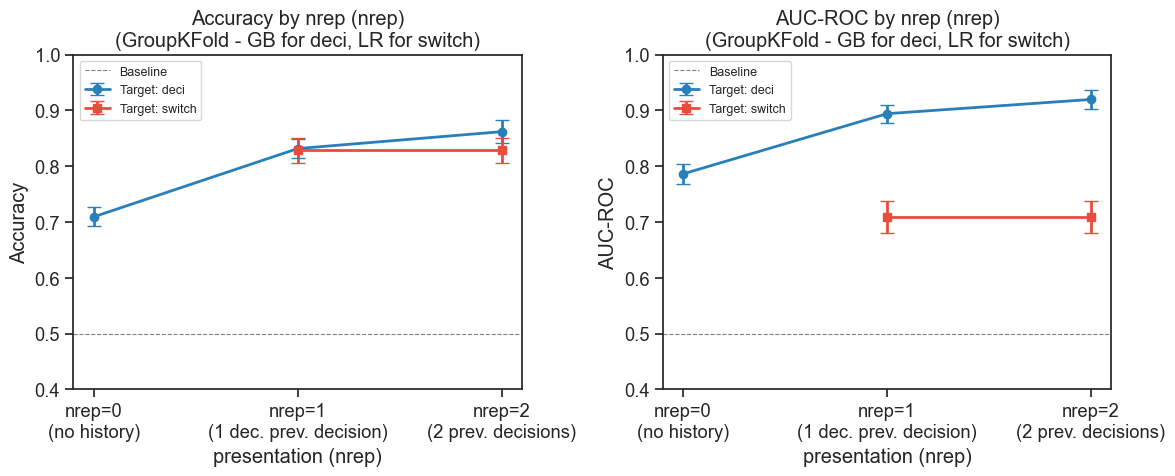

Figure saved: fig_performance_by_nrep.png


In [39]:
# performance by nrep figure 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric, ylabel in [(axes[0], 'acc', 'Accuracy'), (axes[1], 'auc', 'AUC-ROC')]:
    for target_col, color, marker, label in [
        ('deci',   '#2980b9', 'o', 'deci'),
        ('switch', '#e74c3c', 's', 'switch')
    ]:
        nrep_vals, means, stds = [], [], []
        for nrep_val in [0, 1, 2]:
            if nrep_val in results_nrep and target_col in results_nrep[nrep_val]:
                nrep_vals.append(nrep_val)
                means.append(results_nrep[nrep_val][target_col][metric].mean())
                stds.append(results_nrep[nrep_val][target_col][metric].std())
        ax.errorbar(nrep_vals, means, yerr=stds,
                    marker=marker, color=color, linewidth=2,
                    capsize=5, label=f'Target: {label}')

    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Baseline')
    ax.set_xlabel('presentation (nrep)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} by nrep (nrep)\n(GroupKFold - GB for deci, LR for switch)')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['nrep=0\n(no history)', 'nrep=1\n(1 dec. prev. decision)', 'nrep=2\n(2 prev. decisions)'])
    ax.legend(fontsize=9)
    ax.set_ylim(0.4, 1.0)

plt.tight_layout()
plt.savefig('fig_performance_by_nrep.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_performance_by_nrep.png')

In [40]:
# accuracy per participant (Leave One Subject Out) --> analiza si el modelo funciona igual de bien con todos los participantes o si hay diferencias individuales
# LOSO: se entrena en todos menos 1 y se teta en ese 1 (tantos folds como participantes haya)

loso = LeaveOneGroupOut() # creamos el objeto LOSO para generar los splits de entrenamiento y test

# definimos una funcion que calcula la accuracy y el AUC para cada participante usando LOSO
def accuracy_per_subject(X, y, groups, feature_names):

    subj_acc = {}
    subj_auc = {}
    unique_subjs = np.unique(groups) # obtenemos la lista de participantes unicos para iterar sobre ellos

    gb = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier( # usaremos gradient boosting para este analisis de accuracy por participante 
            n_estimators=200, learning_rate=0.05,
            max_depth=3, subsample=0.8, random_state=SEED
        ))
    ])

    for train_idx, test_idx in loso.split(X, y, groups): # iteramos sobre cada fold que genera el LeaveOneGroupOut
        subj_id = str(groups[test_idx[0]])
        X_tr, X_te = X[train_idx], X[test_idx] # dividimos en train y test
        y_tr, y_te = y[train_idx], y[test_idx] # dividimos en train y test

        if len(np.unique(y_te)) < 2: # si el participante de test no tiene ejemplos de ambas clases, no podemos calcular la accuracy ni el AUC, asi que saltamos ese participante
            continue

        gb.fit(X_tr, y_tr) # entrenamos el modelo con todos los demas participantes --> HACE LAS PREDICCIONES
        acc = (gb.predict(X_te) == y_te).mean() # EVALUA EN EL PARTICIPANTE DE TEST
        # calculamos la accuracy comparando las predicciones del modelo con las etiquetas reales de test

        try:
            auc = roc_auc_score(y_te, gb.predict_proba(X_te)[:, 1]) # calculamos el AUC individualmente
        except:
            auc = np.nan

        subj_acc[subj_id] = acc
        subj_auc[subj_id] = auc

    return pd.DataFrame({
        'subj'    : list(subj_acc.keys()),
        'accuracy': list(subj_acc.values()),
        'auc'     : list(subj_auc.values())
    }).sort_values('accuracy', ascending=False).reset_index(drop=True)

print('Computing per participant accuracy (LOSO) - switch...')
subj_sw = accuracy_per_subject(X_sw, y_sw, groups_sw, all_features)

print('Computing per participant accuracy (LOSO) - deci...')
subj_dc = accuracy_per_subject(X_dc, y_dc, groups_dc, all_features)

print(f'\nSwitch — Mean: {subj_sw.accuracy.mean():.3f}  SD: {subj_sw.accuracy.std():.3f}')
print(f'Deci   — Mean: {subj_dc.accuracy.mean():.3f}  SD: {subj_dc.accuracy.std():.3f}')

Computing per participant accuracy (LOSO) - switch...
Computing per participant accuracy (LOSO) - deci...

Switch — Mean: 0.850  SD: 0.074
Deci   — Mean: 0.810  SD: 0.046


In [43]:
# individual accuracy vs behavioural CB metrics 

# para cada participante, calculamos la probabilidad de repetir la decision (p_repeat), la eficiencia metacognitiva (metad_eff) y la confianza media (mean_confi) a partir del dataframe de switch, agrupando por participante (npar)
subj_metrics = df_switch.groupby('npar').agg(
    p_repeat   = ('switch',    lambda x: 1 - x.mean()),
    metad_eff  = ('metad_eff', 'first'),
    mean_confi = ('confi',     'mean')
).reset_index()

subj_metrics['cb_index'] = subj_metrics['p_repeat']

subj_metrics['npar'] = subj_metrics['npar'].astype(str)
subj_sw['subj']      = subj_sw['subj'].astype(str)
subj_dc['subj']      = subj_dc['subj'].astype(str)

# hacemos un merge entre el dataframe de accuracy por participante (subj_sw y subj_dc) y el dataframe de metrics por participante (subj_metrics) para poder analizar la correlacion entre la accuracy individual y las metricas de comportamiento (p_repeat, metad_eff y mean_confi)
merged_sw = subj_sw.merge(subj_metrics, left_on='subj', right_on='npar', how='inner')
merged_dc = subj_dc.merge(subj_metrics, left_on='subj', right_on='npar', how='inner')

print(f'merged_sw rows: {len(merged_sw)}')
print(f'merged_dc rows: {len(merged_dc)}')

print('Correlations: Individual accuracy ~ Behavioural metrics')

print('\nTarget: switch')
for col, label in [
    ('p_repeat',   'p(maintain decision)'),
    ('metad_eff',  'Metacognitive efficiency'),
    ('mean_confi', 'Mean confidence')
]:
    if col in merged_sw.columns:
        tmp = merged_sw[['accuracy', col]].dropna()  # drop NaN across both columns
        if len(tmp) < 2:
            print(f'  {label:30s}: not enough data')
            continue
        r, p = stats.pearsonr(tmp['accuracy'], tmp[col])
        sig = '✓ sig.' if p < 0.05 else 'n.s.'
        print(f'  {label:30s}: r={r:+.3f}, p={p:.4f} {sig}')

print('\nTarget: deci')
for col, label in [
    ('p_repeat',   'p(maintain decision)'),
    ('metad_eff',  'Metacognitive efficiency'),
    ('mean_confi', 'Mean confidence')
]:
    if col in merged_dc.columns:
        tmp = merged_dc[['accuracy', col]].dropna()  # drop NaN across both columns
        if len(tmp) < 2:
            print(f'  {label:30s}: not enough data')
            continue
        r, p = stats.pearsonr(tmp['accuracy'], tmp[col])
        sig = '✓ sig.' if p < 0.05 else 'n.s.'
        print(f'  {label:30s}: r={r:+.3f}, p={p:.4f} {sig}')

merged_sw rows: 24
merged_dc rows: 24
Correlations: Individual accuracy ~ Behavioural metrics

Target: switch
  p(maintain decision)          : r=+0.984, p=0.0000 ✓ sig.
  Metacognitive efficiency      : r=+0.122, p=0.5715 n.s.
  Mean confidence               : r=+0.231, p=0.2773 n.s.

Target: deci
  p(maintain decision)          : r=+0.875, p=0.0000 ✓ sig.
  Metacognitive efficiency      : r=+0.073, p=0.7329 n.s.
  Mean confidence               : r=+0.269, p=0.2039 n.s.


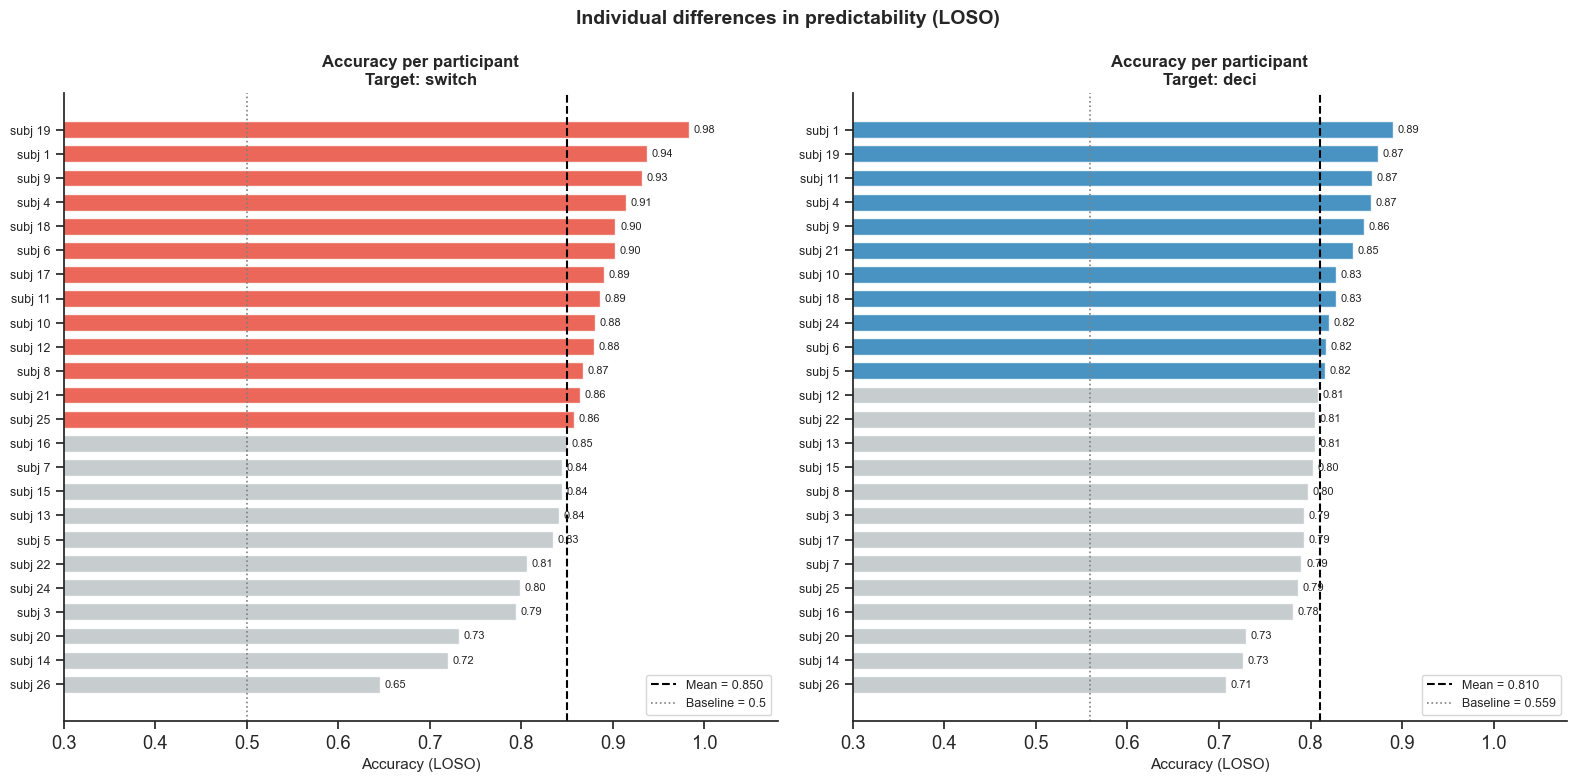

Saved: fig_loso_barras.png
switch ~ p_repeat: r=+0.984, p=0.0000*
deci ~ p_repeat: r=+0.875, p=0.0000*
switch ~ metad_eff: r=+0.122, p=0.5715 (n.s.)
deci ~ metad_eff: r=+0.073, p=0.7329 (n.s.)
switch ~ mean_confi: r=+0.231, p=0.2773 (n.s.)
deci ~ mean_confi: r=+0.269, p=0.2039 (n.s.)


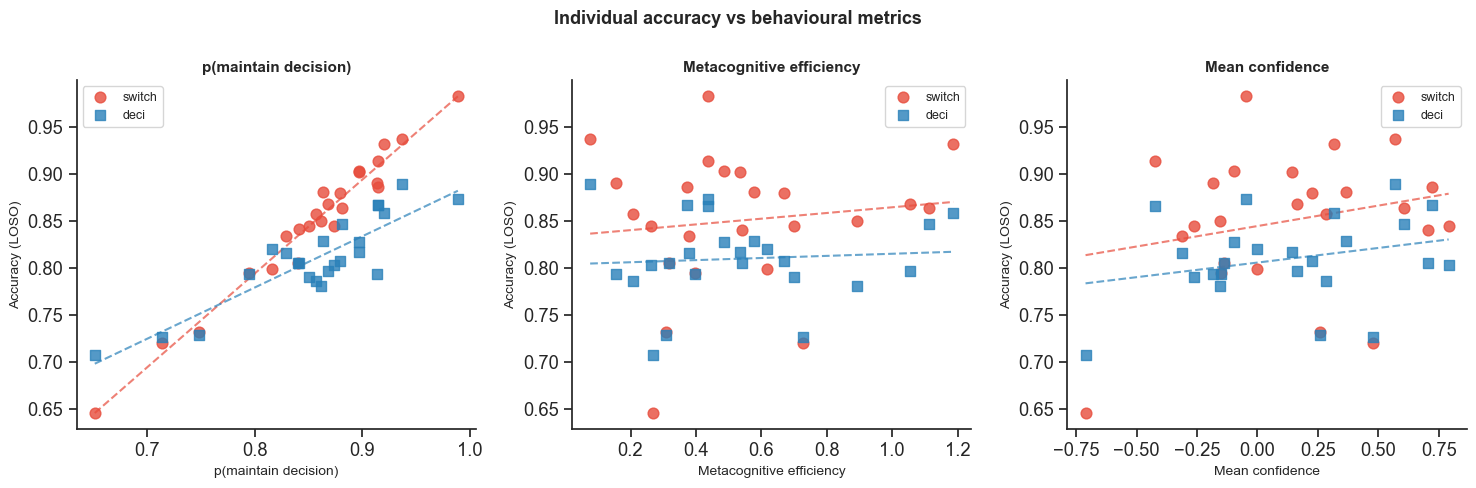

Saved: fig_correlaciones_individuales.png


In [ ]:
# individual differences 
def sns_despine(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# FIGURA 1: accuracy por participante 

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, subj_df, target_label, baseline, color_main in zip(
    axes,
    [subj_sw, subj_dc],
    ['switch', 'deci'],
    [0.5, 0.559],
    ['#e74c3c', '#2980b9']
):
    subj_sorted = subj_df.sort_values('accuracy', ascending=True).reset_index(drop=True)
    mean_acc    = subj_sorted['accuracy'].mean()

    colors = [color_main if a >= mean_acc else '#bdc3c7'
              for a in subj_sorted['accuracy']]

    y_pos = np.arange(len(subj_sorted))

    ax.barh(y_pos, subj_sorted['accuracy'],
            color=colors, alpha=0.85, height=0.7, edgecolor='white')
    ax.axvline(mean_acc, color='black', linestyle='--',
               linewidth=1.5, label=f'Mean = {mean_acc:.3f}')
    ax.axvline(baseline, color='gray', linestyle=':',
               linewidth=1.2, label=f'Baseline = {baseline}')

    ax.set_yticks(y_pos)
    ax.set_yticklabels([f'subj {s}' for s in subj_sorted['subj']], fontsize=9)

    for i, acc in enumerate(subj_sorted['accuracy']):
        ax.text(acc + 0.005, i, f'{acc:.2f}', va='center', fontsize=8)

    ax.set_xlim(0.3, 1.08)
    ax.set_xlabel('Accuracy (LOSO)', fontsize=11)
    ax.set_title(f'Accuracy per participant\nTarget: {target_label}',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    sns_despine(ax)

plt.suptitle('Individual differences in predictability (LOSO)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_loso_barras.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_loso_barras.png')


# FIGURA 2: correlaciones accuracy ~ metricas conductuales 

metrics = [
    ('p_repeat',   'p(maintain decision)'),
    ('metad_eff',  'Metacognitive efficiency'),
    ('mean_confi', 'Mean confidence'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, xlabel) in zip(axes, metrics):
    for merged, color, marker, label in [
        (merged_sw, '#e74c3c', 'o', 'switch'),
        (merged_dc, '#2980b9', 's', 'deci')
    ]:
        tmp = merged[['accuracy', col]].dropna()
        if len(tmp) < 2:
            continue

        ax.scatter(tmp[col], tmp['accuracy'],
                   color=color, marker=marker, s=60,
                   alpha=0.8, label=label, zorder=3)

        m, b = np.polyfit(tmp[col], tmp['accuracy'], 1)
        x_line = np.linspace(tmp[col].min(), tmp[col].max(), 100)
        ax.plot(x_line, m * x_line + b,
                color=color, linewidth=1.5, linestyle='--', alpha=0.7)

        r, p = stats.pearsonr(tmp['accuracy'], tmp[col])
        sig   = '*' if p < 0.05 else ' (n.s.)'
        print(f'{label} ~ {col}: r={r:+.3f}, p={p:.4f}{sig}')

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Accuracy (LOSO)', fontsize=10)
    ax.set_title(xlabel, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    sns_despine(ax)

plt.suptitle('Individual accuracy vs behavioural metrics',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlaciones_individuales.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_correlaciones_individuales.png')

In [46]:
# full summary table 

print('=' * 70)
print('FINAL SUMMARY — MACHINE LEARNING ANALYSIS')
print('=' * 70)

print('\n── Validation: GroupKFold (k=5, groups = participants) ──────────────')
print('   All performance results reflect generalisation to new participants')

print('\n── TARGET 1: switch (decision change?) ──────────────────────────────')
for name, res in results_sw.items():
    print(f'  {name:22s}  Acc={res["acc_test"].mean():.3f}±{res["acc_test"].std():.3f}'
          f'  AUC={res["auc_test"].mean():.3f}±{res["auc_test"].std():.3f}'
          f'  F1={res["f1_test"].mean():.3f}')

print('\n── TARGET 2: deci (cardinal vs diagonal) ────────────────────────────')
for name, res in results_dc.items():
    print(f'  {name:22s}  Acc={res["acc_test"].mean():.3f}±{res["acc_test"].std():.3f}'
          f'  AUC={res["auc_test"].mean():.3f}±{res["auc_test"].std():.3f}'
          f'  F1={res["f1_test"].mean():.3f}')

print('\n── Feature ablation (LR for switch / RF for deci) ───────────────────')
for feat_label, res in ablation_results.items():
    label_clean = feat_label.replace('\n', ' ')
    if 'switch' in res:
        print(f'  {label_clean:45s}  Acc={res["switch"]["acc"]:.3f}  AUC={res["switch"]["auc"]:.3f}')

print('\n── Top 5 variables — switch (permutation importance, AUC) ──────────')
for _, row in perm_sw.head(5).iterrows():
    print(f'  {row["feature"]:12s}: {row["imp_mean"]:+.4f} ± {row["imp_std"]:.4f}')

print('\n── diferencias individuales (LOSO) ──────────────────────────────────')
print(f'  Switch — Mean Acc: {subj_sw.accuracy.mean():.3f}  SD: {subj_sw.accuracy.std():.3f}')
print(f'  Deci   — Mean Acc: {subj_dc.accuracy.mean():.3f}  SD: {subj_dc.accuracy.std():.3f}')

FINAL SUMMARY — MACHINE LEARNING ANALYSIS

── Validation: GroupKFold (k=5, groups = participants) ──────────────
   All performance results reflect generalisation to new participants

── TARGET 1: switch (decision change?) ──────────────────────────────
  Logistic Regression     Acc=0.677±0.018  AUC=0.735±0.014  F1=0.368
  SVM (lineal)            Acc=0.678±0.027  AUC=0.731±0.011  F1=0.375
  Random Forest           Acc=0.729±0.030  AUC=0.745±0.012  F1=0.367
  Gradient Boosting       Acc=0.841±0.027  AUC=0.737±0.013  F1=0.132

── TARGET 2: deci (cardinal vs diagonal) ────────────────────────────
  Logistic Regression     Acc=0.784±0.015  AUC=0.861±0.010  F1=0.799
  SVM (lineal)            Acc=0.763±0.024  AUC=0.852±0.015  F1=0.785
  Random Forest           Acc=0.811±0.011  AUC=0.885±0.011  F1=0.826
  Gradient Boosting       Acc=0.803±0.009  AUC=0.879±0.013  F1=0.823

── Feature ablation (LR for switch / RF for deci) ───────────────────
  1. Sensory                                     Acc

In [47]:
# save results to CSV 

import os
os.makedirs('ml_results', exist_ok=True)

rows_sw, rows_dc = [], []
for name, res in results_sw.items():
    rows_sw.append({'model': name, 'target': 'switch',
                    'acc_mean': res['acc_test'].mean(), 'acc_std': res['acc_test'].std(),
                    'auc_mean': res['auc_test'].mean(), 'auc_std': res['auc_test'].std(),
                    'f1_mean' : res['f1_test'].mean()})
for name, res in results_dc.items():
    rows_dc.append({'model': name, 'target': 'deci',
                    'acc_mean': res['acc_test'].mean(), 'acc_std': res['acc_test'].std(),
                    'auc_mean': res['auc_test'].mean(), 'auc_std': res['auc_test'].std(),
                    'f1_mean' : res['f1_test'].mean()})

pd.DataFrame(rows_sw + rows_dc).round(4).to_csv('ml_results/model_performance.csv', index=False)
perm_sw.round(4).to_csv('ml_results/perm_importance_switch.csv', index=False)
perm_dc.round(4).to_csv('ml_results/perm_importance_deci.csv', index=False)
subj_sw.round(4).to_csv('ml_results/subject_accuracy_switch.csv', index=False)
subj_dc.round(4).to_csv('ml_results/subject_accuracy_deci.csv', index=False)

print('results saved to ml_results/')
print('  - model_performance.csv')
print('  - perm_importance_switch.csv')
print('  - perm_importance_deci.csv')
print('  - subject_accuracy_switch.csv')
print('  - subject_accuracy_deci.csv')

results saved to ml_results/
  - model_performance.csv
  - perm_importance_switch.csv
  - perm_importance_deci.csv
  - subject_accuracy_switch.csv
  - subject_accuracy_deci.csv
